# Does the palm-oil price predict forest loss?

This is the economic half of the project. I pair **annual forest loss** in the AOI with the **global palm-oil price** and test whether price moves predict clearing, possibly with a lag (clear land when palm is profitable, harvest later).

**Why Hansen, not U-Net here:** Notebook 6 showed a 3-snapshot model difference is too noisy and conflates plantation with forest. **Hansen Global Forest Change** gives a consistent *annual* record of tree-cover **loss events** for 2001–2023, where around 23 data points makes a regression meaningful.

In [1]:
!pip install -q earthengine-api statsmodels
import ee, numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project="landcover-riau")

## 1. Annual forest loss from Hansen (2001–2023)

The `lossyear` band encodes the year each pixel lost tree cover (1 = 2001 … 23 = 2023). I restrict to pixels that were real forest in 2000 (`treecover2000 ≥ 30%`), then sum the lost **area** grouped by year.

In [3]:
AOI_BBOX = [102.9, -0.6, 103.4, -0.1]
region = ee.Geometry.Rectangle(AOI_BBOX)
TC_THRESHOLD = 30        # % canopy in 2000 to count as 'forest'

gfc = ee.Image("UMD/hansen/global_forest_change_2025_v1_13").clip(region)
forest2000 = gfc.select("treecover2000").gte(TC_THRESHOLD)
loss = gfc.select("loss").And(forest2000)
lossyear = gfc.select("lossyear").updateMask(loss)
area = ee.Image.pixelArea().updateMask(loss)        # m^2 of lost forest

groups = area.addBands(lossyear).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName="yr"),
    geometry=region, scale=30, maxPixels=1e10,
).getInfo()["groups"]

loss_df = (pd.DataFrame([{"year": 2000 + g["yr"], "loss_km2": g["sum"] / 1e6} for g in groups])
           .query("year >= 2001").sort_values("year").reset_index(drop=True))
print(loss_df.to_string(index=False))
print(f"\ntotal forest lost 2001-2023: {loss_df.loss_km2.sum():.1f} km^2")

 year  loss_km2
 2001  9.452473
 2002  9.238677
 2003  6.759891
 2004 35.697522
 2005 47.077421
 2006 36.322524
 2007 53.122494
 2008 17.656247
 2009  7.320166
 2010 54.080690
 2011 58.203612
 2012 84.002729
 2013 33.224974
 2014 97.755976
 2015 25.854552
 2016 48.428725
 2017 51.435698
 2018 49.120494
 2019 47.973729
 2020 39.271232
 2021 21.723723
 2022 14.095876
 2023 33.433520
 2024 21.225191
 2025 50.279764

total forest lost 2001-2023: 952.8 km^2


## 2. Global palm-oil price

Annual average of the global palm-oil price (USD / metric ton), from FRED series `PPALPLUSDM` (IMF / World Bank primary-commodity prices).

In [8]:
import pandas as pd
# Global palm-oil price, annual average, nominal USD / metric ton.
# Source: World Bank Commodity Markets "Pink Sheet", Annual Prices (Nominal),
# "Palm oil" column (cached inline — analysis kernel is offline).
palm = {
    2001: 287.46, 2002: 410.90, 2003: 476.70, 2004: 499.28, 2005: 450.56,
    2006: 508.30, 2007: 816.69, 2008: 1042.92, 2009: 741.15, 2010: 933.02,
    2011: 1193.37, 2012: 1043.40, 2013: 870.73, 2014: 837.47, 2015: 663.39,
    2016: 735.70, 2017: 750.81, 2018: 638.66, 2019: 601.37, 2020: 751.77,
    2021: 1130.58, 2022: 1275.99, 2023: 886.45, 2024: 963.36,
}
price = pd.Series(palm, name="palm_usd"); price.index.name = "year"
print(price.round(0).to_string())

year
2001     287.0
2002     411.0
2003     477.0
2004     499.0
2005     451.0
2006     508.0
2007     817.0
2008    1043.0
2009     741.0
2010     933.0
2011    1193.0
2012    1043.0
2013     871.0
2014     837.0
2015     663.0
2016     736.0
2017     751.0
2018     639.0
2019     601.0
2020     752.0
2021    1131.0
2022    1276.0
2023     886.0
2024     963.0


## 3. Lagged regression

Merge the two series and regress forest loss on the palm price at several lags.

In [9]:
df = loss_df.set_index("year").join(price).dropna()

results = {}
print("OLS:  forest_loss ~ palm_price(t - lag)")
for lag in range(0, 4):
    d = df.assign(price_lag=df["palm_usd"].shift(lag)).dropna()
    res = sm.OLS(d["loss_km2"], sm.add_constant(d["price_lag"])).fit()
    results[lag] = (res, d)
    print(f"  lag {lag}y:  n={int(res.nobs)}  R2={res.rsquared:.3f}  "
          f"slope={res.params['price_lag']:+.4f}  p={res.pvalues['price_lag']:.3f}")

best_lag = max(results, key=lambda L: results[L][0].rsquared)
print(f"\nbest fit at lag = {best_lag} year(s)")

OLS:  forest_loss ~ palm_price(t - lag)
  lag 0y:  n=24  R2=0.048  slope=+0.0196  p=0.304
  lag 1y:  n=23  R2=0.025  slope=+0.0138  p=0.472
  lag 2y:  n=22  R2=0.053  slope=+0.0195  p=0.301
  lag 3y:  n=21  R2=0.127  slope=+0.0314  p=0.113

best fit at lag = 3 year(s)


## 4. Plots

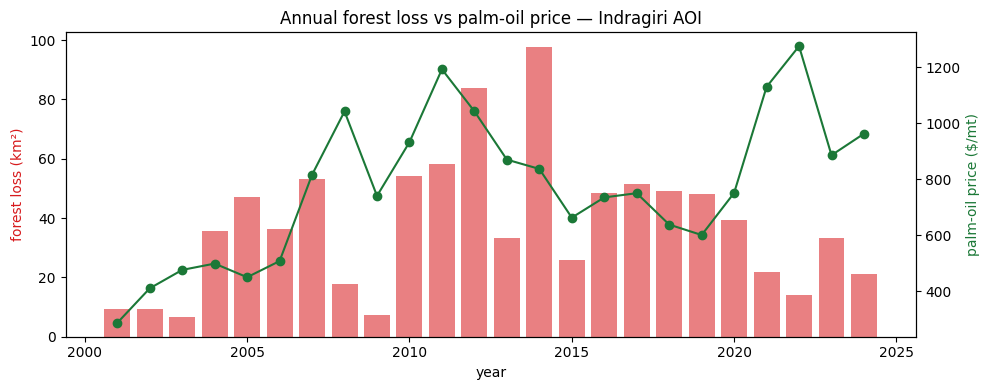

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(df.index, df["loss_km2"], color="#d7191c", alpha=0.55)
ax1.set_ylabel("forest loss (km²)", color="#d7191c"); ax1.set_xlabel("year")
ax2 = ax1.twinx()
ax2.plot(df.index, df["palm_usd"], "o-", color="#1b7837")
ax2.set_ylabel("palm-oil price ($/mt)", color="#1b7837")
ax1.set_title("Annual forest loss vs palm-oil price — Indragiri AOI")
plt.tight_layout(); plt.show()

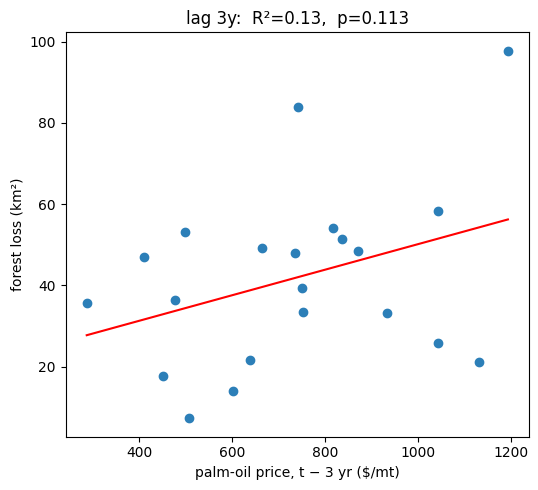

In [11]:
res, d = results[best_lag]
xs = np.linspace(d["price_lag"].min(), d["price_lag"].max(), 50)
plt.figure(figsize=(5.5, 5))
plt.scatter(d["price_lag"], d["loss_km2"], color="#2c7fb8")
plt.plot(xs, res.params["const"] + res.params["price_lag"] * xs, color="red")
plt.xlabel(f"palm-oil price, t − {best_lag} yr ($/mt)"); plt.ylabel("forest loss (km²)")
plt.title(f"lag {best_lag}y:  R²={res.rsquared:.2f},  p={res.pvalues['price_lag']:.3f}")
plt.tight_layout(); plt.show()

## 5. Findings

Across 0–3 year lags, palm-oil price shows a **weak, positive, statistically non-significant** association with annual forest loss in this AOI. The fit strengthens with lag, best at a **3-year lag (R² = 0.13, slope +0.03, p = 0.11)**, and *every* lag has a positive slope, hinting that price rises may be followed by clearing a few years later. However, with p ≈ 0.11 I cannot reject "no relationship".

**Why the signal is weak (and why that's expected):**
- **Small N**: only ~21–24 yearly points, and OLS p-values are optimistic here because forest loss is autocorrelated year-to-year.
- **Scale mismatch**: the price is *global*, but loss is one ~3,000 km² AOI, where clearing is driven as much by concessions, roads, and policy as by world price.
- **Confounders**: the 2011 forest moratorium, the 2015 fire/haze year, COVID, and multi-year replanting cycles all move loss independently of price.

**The pairing is the point.** The U-Net delivers high-detail land-cover maps (the CV showcase); Hansen + price delivers the long, testable economic series. Two methods, two scales, and the economics showing price *alone* doesn't explain local clearing is itself a finding.